In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RandomizedSearchCV
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

Base sem quali

In [20]:
df_sem_quali = pd.read_csv(r"DATA\oficial.csv")
df_sem_quali.drop(columns=["posicao_quali_atual", "q1_atual", "q2_atual", "q3_atual", "dif_para_pole_atual"], inplace=True)
df_sem_quali.head()

,temporada_atual,rodada_atual,id_piloto_atual,target,id_circuito_atual,id_equipe_atual,grid_anterior,posicao_ultima_corrida,status,pontos_anterior_individual,...,media_ultimas_3_anterior,media_ultimas_5_anterior,qtde_abandonos_anterior,media_posicao_ganha_anterior,tendencia_desempenho,temp_ar_media,temp_pista_media,umidade_media,corrida_molhada,perc_voltas_chuva
0,2018,1,alonso,5,albert_park,mclaren,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,24.08,36.32,30.92,0,4.5
1,2018,1,bottas,8,albert_park,mercedes,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,24.08,36.32,30.92,0,4.5
2,2018,1,brendon_hartley,15,albert_park,toro_rosso,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,24.08,36.32,30.92,0,4.5
3,2018,1,ericsson,19,albert_park,sauber,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,24.08,36.32,30.92,0,4.5
4,2018,1,gasly,18,albert_park,toro_rosso,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,24.08,36.32,30.92,0,4.5


In [21]:
df_sem_quali["target"] = (df_sem_quali["target"] <= 3).astype(int)

In [22]:
df_sem_quali["posicao_equipe_anterior"] = pd.to_numeric(df_sem_quali["posicao_equipe_anterior"], errors="coerce")

df_sem_quali.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3590 entries, 0 to 3589
Data columns (total 26 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   temporada_atual               3590 non-null   int64  
 1   rodada_atual                  3590 non-null   int64  
 2   id_piloto_atual               3590 non-null   object 
 3   target                        3590 non-null   int32  
 4   id_circuito_atual             3590 non-null   object 
 5   id_equipe_atual               3590 non-null   object 
 6   grid_anterior                 3381 non-null   float64
 7   posicao_ultima_corrida        3381 non-null   float64
 8   status                        3381 non-null   object 
 9   pontos_anterior_individual    3381 non-null   float64
 10  posicao_equipe_anterior       3404 non-null   float64
 11  pontos_equipe_anterior        3408 non-null   float64
 12  vitorias_equipe_anterior      3408 non-null   float64
 13  pon

In [23]:
df_sem_quali.describe()

,temporada_atual,rodada_atual,target,grid_anterior,posicao_ultima_corrida,pontos_anterior_individual,posicao_equipe_anterior,pontos_equipe_anterior,vitorias_equipe_anterior,pontos_anterior,...,media_ultimas_3_anterior,media_ultimas_5_anterior,qtde_abandonos_anterior,media_posicao_ganha_anterior,tendencia_desempenho,temp_ar_media,temp_pista_media,umidade_media,corrida_molhada,perc_voltas_chuva
count,3590.000000,3590.000000,3590.000000,3381.000000,3381.000000,3381.000000,3404.000000,3408.000000,3408.000000,3395.000000,...,3395.000000,3395.000000,3395.000000,3395.000000,3395.000000,3590.000000,3590.000000,3590.000000,3590.000000,3590.000000
mean,2021.805850,11.122563,0.149582,10.264123,10.508429,5.074091,5.509694,112.372653,1.065728,56.228571,...,10.512197,10.511137,1.144624,-0.240200,0.001060,23.397187,35.273671,53.775253,0.033426,5.389861
std,2.415682,6.456837,0.356711,5.818943,5.786564,7.216828,2.881879,152.075410,2.686500,79.772816,...,4.662668,4.429625,1.284052,3.336187,1.471952,4.909411,9.075277,16.541314,0.179772,16.324197
min,2018.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,...,1.000000,1.000000,0.000000,-18.000000,-6.800000,9.500000,15.210000,7.110000,0.000000,0.000000
25%,2020.000000,5.000000,0.000000,5.000000,5.000000,0.000000,3.000000,12.000000,0.000000,4.000000,...,7.000000,7.000000,0.000000,-2.000000,-0.730000,20.120000,28.970000,42.320000,0.000000,0.000000
50%,2022.000000,11.000000,0.000000,10.000000,11.000000,0.000000,6.000000,46.000000,0.000000,22.000000,...,11.000000,11.200000,1.000000,0.000000,0.000000,23.200000,35.230000,54.720000,0.000000,0.000000
75%,2024.000000,17.000000,0.000000,15.000000,16.000000,9.000000,8.000000,148.000000,0.000000,72.000000,...,14.330000,14.000000,2.000000,2.000000,0.740000,27.130000,42.030000,63.900000,0.000000,0.500000
max,2026.000000,24.000000,1.000000,22.000000,22.000000,26.000000,11.000000,822.000000,20.000000,549.000000,...,22.000000,22.000000,8.000000,14.000000,5.530000,36.570000,54.530000,96.440000,1.000000,98.000000


In [24]:
df_sem_quali.drop(columns=["id_piloto_atual"], inplace=True)

In [25]:
X = df_sem_quali.drop(columns=['target'])
y = df_sem_quali['target']

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [27]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [28]:
onehotencoder = ColumnTransformer(transformers=[
    ('OneHot', OneHotEncoder(handle_unknown='ignore'), ['id_circuito_atual', 'id_equipe_atual', 'status'])
], remainder='passthrough')

In [29]:
X_train_transformed = onehotencoder.fit_transform(X_train)
X_test_transformed = onehotencoder.transform(X_test)

In [30]:
param_grid = {
    "max_depth": [3, 4, 5],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "n_estimators": [100, 200, 300],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "scale_pos_weight": [1, 3, 5.35, 7, 10]
}

xgb_model = xgb.XGBClassifier(random_state=42)

grid_search = RandomizedSearchCV(xgb_model, param_grid, cv=10, scoring="accuracy", n_iter=100, n_jobs=-1, verbose=2, random_state=42)
grid_search.fit(X_train_transformed, y_train)

best_xgb = grid_search.best_estimator_

print("Melhores parâmetros:", grid_search.best_params_)
print("Melhor acurácia:", grid_search.best_score_)

Fitting 10 folds for each of 100 candidates, totalling 1000 fits
Melhores parâmetros: {'subsample': 1.0, 'scale_pos_weight': 1, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 0.9}
Melhor acurácia: 0.877801974448316


In [31]:
y_pred = best_xgb.predict(X_test_transformed)

test_accuracy = accuracy_score(y_test, y_pred)
print("Acurácia: ", test_accuracy)

print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nMatriz de confusão:\n", confusion_matrix(y_test, y_pred))

Acurácia:  0.871866295264624

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.94      0.93       605
           1       0.61      0.50      0.55       113

    accuracy                           0.87       718
   macro avg       0.76      0.72      0.74       718
weighted avg       0.86      0.87      0.87       718


Matriz de confusão:
 [[569  36]
 [ 56  57]]


Entendendo as features utilizadas

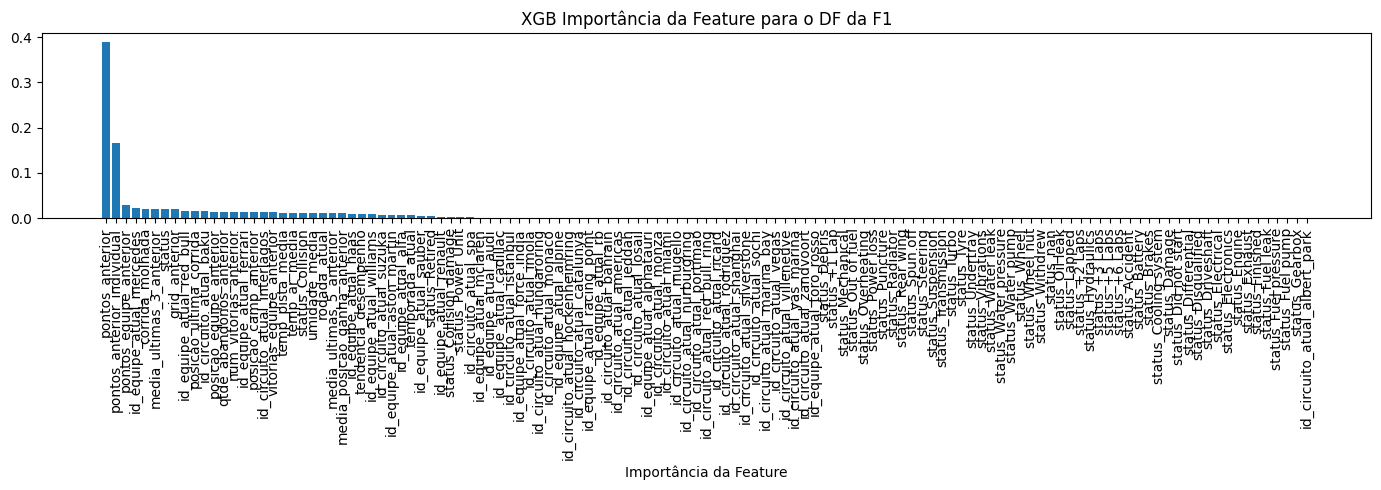

In [32]:
colunas_ohe = onehotencoder.named_transformers_['OneHot'].get_feature_names_out(['id_circuito_atual', 'id_equipe_atual', 'status'])
colunas_resto = [c for c in X.columns if c not in ['id_circuito_atual', 'id_equipe_atual']]
feature_names = list(colunas_ohe) + list(colunas_resto)

feature_importances = best_xgb.feature_importances_
sorted_indices = np.argsort(feature_importances)[::-1]

plt.figure(figsize=(14, 5))
plt.bar(range(len(feature_importances)), feature_importances[sorted_indices], align="center")
plt.xticks(range(len(feature_importances)), np.array(feature_names)[sorted_indices], rotation=90)
plt.xlabel("Importância da Feature")
plt.title("XGB Importância da Feature para o DF da F1")
plt.tight_layout()
plt.show()

In [33]:
import joblib

joblib.dump(best_xgb, r"modelos\modelo_sem_quali.pkl")
joblib.dump(onehotencoder, r"modelos\encoder_sem_quali.pkl")

['modelos\\encoder_sem_quali.pkl']

# Testes

In [1]:
import joblib
import pandas as pd

modelo = joblib.load(r"modelos\modelo_sem_quali.pkl")
encoder = joblib.load(r"modelos\encoder_sem_quali.pkl")

df = pd.read_csv(r"DATA\analise.csv")

X_train_transformed = encoder.transform(df)
predicoes = modelo.predict_proba(X_train_transformed)

print(predicoes)

[[0.3267169  0.6732831 ]
 [0.43139684 0.56860316]
 [0.2717772  0.7282228 ]
 [0.840941   0.15905897]
 [0.765128   0.23487195]
 [0.92419076 0.07580922]
 [0.937127   0.06287298]
 [0.97126514 0.02873489]
 [0.97301847 0.02698154]
 [0.98415494 0.01584507]
 [0.9938574  0.00614261]
 [0.9950696  0.00493038]
 [0.99650306 0.00349697]
 [0.9921659  0.00783405]
 [0.5642354  0.4357646 ]
 [0.23063248 0.7693675 ]
 [0.9972214  0.00277858]
 [0.9957386  0.00426137]
 [0.99568677 0.00431325]
 [0.9952939  0.00470608]
 [0.9890649  0.01093512]
 [0.9957087  0.00429131]]


In [5]:
probs = modelo.predict_proba(X_train_transformed)[:, 1]

df_result = df.copy()
df_result['prob_podio'] = probs
df_result['predicao'] = modelo.predict(X_train_transformed)

print(df_result[['id_piloto_atual', 'prob_podio', 'predicao']]
      .sort_values('prob_podio', ascending=False))

   id_piloto_atual  prob_podio  predicao
15       antonelli    0.769368         1
2           norris    0.728223         1
0         hamilton    0.673283         1
1          russell    0.568603         1
14         leclerc    0.435765         0
4          piastri    0.234872         0
3   max_verstappen    0.159059         0
5           hadjar    0.075809         0
6            gasly    0.062873         0
7        colapinto    0.028735         0
8           lawson    0.026982         0
9   arvid_lindblad    0.015845         0
20          bottas    0.010935         0
13           perez    0.007834         0
10       bortoleto    0.006143         0
11           sainz    0.004930         0
19      hulkenberg    0.004706         0
18          alonso    0.004313         0
21          stroll    0.004291         0
17           albon    0.004261         0
12            ocon    0.003497         0
16         bearman    0.002779         0


In [2]:
import os
import streamlit as st
from google.cloud import storage
from google.oauth2 import service_account
import pickle

def salva_gcs(caminho_gcs, caminho_local):
    os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "clever-axe-457319-g8-833d2d4ab67f.json"

    client = client = storage.Client()
    bucket = client.bucket("f1-dashboard-pilotos")
    blob = bucket.blob(caminho_gcs)

    blob.upload_from_filename(caminho_local)

modelos = [
    ("modelos/modelo_sem_quali.pkl",  r"modelos\modelo_sem_quali.pkl"),
    ("modelos/encoder_sem_quali.pkl", r"modelos\encoder_sem_quali.pkl"),
]
for caminho_gcs, caminho_local in modelos:
    salva_gcs(caminho_gcs, caminho_local)